In [1]:
import pandas as pd
import numpy as np
df_meddra_all_se = pd.read_csv("../../Data/meddra_all_se.tsv", sep="\t", header=None,
                 names=["CID","STITCH_CID", "UMLS_ID", "UMS_Concept_ID", "Source", "ADR_NAME"])
df_meddra_all_indications = pd.read_csv("../../Data/meddra_all_indications.tsv", sep="\t", header=None,
                 names=["CID", "UMLS_ID", "text", "name", "name2","ID", "name4"])
df_adr_UMLS = pd.read_csv("../../Data/ADR_Path_Lesk_sim.csv", sep=",", header=None)


In [2]:
ADR_CUI = pd.read_csv("../../Data/ADR_CUI_TO_NAME.csv", header=None,
                 names=["CUI","ADR_NAME"])
cui_to_index = {cid: i for i, cid in enumerate(ADR_CUI["CUI"].tolist())}

df_fp = pd.read_csv("../../Data/indications_drug_fingerprints_881.csv")
drug_list = df_fp["CID"].unique()

CUI_list = df_meddra_all_se['UMLS_ID'].unique()


In [3]:
# df_fp = pd.read_csv("../Data/indications_drug_fingerprints_881.csv")

cid_to_index = {cid: i for i, cid in enumerate(df_fp["CID"].tolist())}

df_meddra_all_se["new_CID"] = df_meddra_all_se["CID"].str.extract(r"CID(\d+)").astype(float).astype(int)
df_meddra_all_indications["new_CID"] = df_meddra_all_indications["CID"].str.extract(r"CID(\d+)").astype(float).astype(int)


In [4]:
adr_counts = df_meddra_all_se["UMLS_ID"].value_counts()


rare_adr = adr_counts[adr_counts <= 5].index.tolist()
common_adr = adr_counts[adr_counts > 5].index.tolist()
print("Rare ADRs:", len(rare_adr))
print("Common ADRs:", len(common_adr))

Rare ADRs: 2661
Common ADRs: 3207


In [5]:
import pandas as pd
import numpy as np
import ast
from sklearn.metrics.pairwise import cosine_similarity


df_fp["Fingerprint"] = df_fp["Fingerprint"].apply(ast.literal_eval)


X = np.array(df_fp["Fingerprint"].tolist(), dtype=float) 


cos_sim_matrix = cosine_similarity(X)


cos_sim_df = pd.DataFrame(cos_sim_matrix, index=df_fp["CID"], columns=df_fp["CID"])
cos_sim_df.to_csv("../../Data/drug_fingerprint_cosine_similarity.csv", index=False, header=False)

print(cos_sim_df.head())


CID        100000085  100000119  100000137  100000143  100000158  100000159  \
CID                                                                           
100000085   1.000000   0.639877   0.675923   0.233786   0.652929   0.216777   
100000119   0.639877   1.000000   0.743161   0.192232   0.639137   0.183340   
100000137   0.675923   0.743161   1.000000   0.240192   0.670820   0.200446   
100000143   0.233786   0.192232   0.240192   1.000000   0.214834   0.213980   
100000158   0.652929   0.639137   0.670820   0.214834   1.000000   0.199205   

CID        100000175  100000187  100000191  100000206  ...  153627505  \
CID                                                    ...              
100000085   0.666726   0.349983   0.349983   0.290191  ...   0.236842   
100000119   0.817632   0.277498   0.277498   0.178958  ...   0.139104   
100000137   0.684996   0.337100   0.337100   0.198762  ...   0.189258   
100000143   0.263249   0.302283   0.302283   0.167093  ...   0.129881   
10000015

In [ ]:
import ast
positive_data = []
count = 0
test_positive_data = []
for index, row in df_meddra_all_se.iterrows():
    # if(count == 0):
        if row['new_CID'] in drug_list and row['UMLS_ID'] in CUI_list and row['UMLS_ID'] not in rare_adr:
            ADR_index = cui_to_index[row['UMLS_ID']]
            ADR = df_adr_UMLS.iloc[ADR_index].tolist()
            # print(ADR)
            count += 1
            # ADR_list = [float(x) for x in ADR[0].split(',')]
            
            drug_index = cid_to_index[row['new_CID']]
            drug_row = cos_sim_df.iloc[drug_index].tolist()
            # drug = ADR_list = [float(x) for x in ADR[0].split(',')]
            
            # drug_row = df_fp.iloc[cid_to_index[row['new_CID']]]["Fingerprint"]
            # fingerprint_list = ast.literal_eval(drug_row)
            # fingerprint_array = np.array(fingerprint_list, dtype=int)
            
            
            emb = np.concatenate([drug_row, ADR])
            print(len(emb),len(drug_row), len(ADR))
            # print(emb[1:100])
            positive_data.append(emb)                    
        elif row['new_CID'] in drug_list and row['UMLS_ID'] in CUI_list and row['UMLS_ID'] in rare_adr:   
            ADR_index = cui_to_index[row['UMLS_ID']]
            ADR = df_adr_UMLS.iloc[ADR_index].tolist()
            count += 1
            # ADR_list = [float(x) for x in ADR[0].split(',')]
            # print(ADR_list)
            
            drug_index = cid_to_index[row['new_CID']]
            drug_row = cos_sim_df.iloc[drug_index].tolist()
            # drug = ADR_list = [float(x) for x in ADR[0].split(',')]
            
            # drug_row = df_fp.iloc[cid_to_index[row['new_CID']]]["Fingerprint"]
            # fingerprint_list = ast.literal_eval(drug_row)
            # fingerprint_array = np.array(fingerprint_list, dtype=int)
                
            emb = np.concatenate([drug_row, ADR])
           
            test_positive_data.append(emb)  

7233 1365 5868


In [7]:
positive_data[0]

array([1.        , 0.63987712, 0.67592259, ..., 0.0625    , 0.125     ,
       0.0625    ])

In [ ]:
# df_positive = pd.DataFrame(positive_data)


# df_positive.to_csv("positive_data.csv", index=False)

In [ ]:
import ast
negative_data = []
count = 0
test_negative_data = []
for index, row in df_meddra_all_indications.iterrows():
    # if(count == 0):
        if row['new_CID'] in drug_list and row['UMLS_ID'] in CUI_list and row['UMLS_ID'] not in rare_adr:
            ADR_index = cui_to_index[row['UMLS_ID']]
            ADR = df_adr_UMLS.iloc[ADR_index].tolist()
            count += 1
            # ADR_list = [float(x) for x in ADR[0].split(',')]
           
            drug_index = cid_to_index[row['new_CID']]
            drug_row = cos_sim_df.iloc[drug_index].tolist()
            # drug = ADR_list = [float(x) for x in ADR[0].split(',')]
           
            # print(ADR_list)
            # drug_row = df_fp.iloc[cid_to_index[row['new_CID']]]["Fingerprint"]
            # fingerprint_list = ast.literal_eval(drug_row)
            # fingerprint_array = np.array(fingerprint_list, dtype=int)
                
            emb = np.concatenate([drug_row, ADR])
            # print(emb[1:100])
            negative_data.append(emb)   
        elif row['new_CID'] in drug_list and row['UMLS_ID'] in CUI_list and row['UMLS_ID'] in rare_adr:   
            ADR_index = cui_to_index[row['UMLS_ID']]
            ADR = df_adr_UMLS.iloc[ADR_index].tolist()
            count += 1
            # ADR_list = [float(x) for x in ADR[0].split(',')]
            # print(ADR_list)
            
            drug_index = cid_to_index[row['new_CID']]
            drug_row = cos_sim_df.iloc[drug_index].tolist()
            # drug = ADR_list = [float(x) for x in ADR[0].split(',')]
            
            # drug_row = df_fp.iloc[cid_to_index[row['new_CID']]]["Fingerprint"]
            # fingerprint_list = ast.literal_eval(drug_row)
            # fingerprint_array = np.array(fingerprint_list, dtype=int)
                
            emb = np.concatenate([drug_row, ADR])
            # print(emb[1:100])
            test_negative_data.append(emb)  

In [ ]:
# df_negative = pd.DataFrame(negative_data)


# df_negative.to_csv("negative_data.csv", index=False)

In [9]:
len(negative_data), len(positive_data)
# 25301
# (22394, 282680)

(22394, 282680)

In [10]:
import random
P = positive_data.copy()
N = negative_data.copy()



test_data = test_positive_data + test_negative_data
test_label = [1]*len(test_positive_data) + [0]*len(test_negative_data)

len(N), len(negative_data), len(test_data)

(22394, 22394, 9410)

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:

P_size = len(P)
N_size = len(N)
if(P_size % N_size < N_size/2):
    n = P_size % N_size + N_size
    print("YES")
    
else:
    n = P_size % N_size
indices = np.random.choice(len(P), n, replace=False)
train_i_positive_data = [P[i] for i in indices]
for i in sorted(indices, reverse=True):
    del P[i]
    
train_i_label = [1]*len(train_i_positive_data) + [0]*len(N)
train_i = train_i_positive_data + N
rf_models = [] 



X_train = train_i
y_train = train_i_label
#train an RF
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_models.append(rf) 

In [13]:
y_pred = rf_models[0].predict(test_data)
    
all_preds = []
all_preds.append(y_pred)

print("Accuracy:", accuracy_score(test_label, y_pred))
print("Confusion Matrix:\n", confusion_matrix(test_label, y_pred))
print("Classification Report:\n", classification_report(test_label, y_pred))

Accuracy: 0.6936238044633368
Confusion Matrix:
 [[2303  604]
 [2279 4224]]
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.79      0.62      2907
           1       0.87      0.65      0.75      6503

    accuracy                           0.69      9410
   macro avg       0.69      0.72      0.68      9410
weighted avg       0.76      0.69      0.71      9410



In [14]:
len(P)/N_size

12.0

In [15]:
while len(P)!=0:
    n = N_size
    indices = np.random.choice(len(P), n, replace=False)
    train_i_positive_data = [P[i] for i in indices]
    for i in sorted(indices, reverse=True):
        del P[i]
    train_i_label = [1]*len(train_i_positive_data) + [0]*len(N)
    train_i = train_i_positive_data + N
    X_train = train_i
    y_train = train_i_label
    rf = RandomForestClassifier(n_estimators=50)
    rf.fit(X_train, y_train)
    rf_models.append(rf)
    print("size:",len(train_i))

size: 44788
size: 44788
size: 44788
size: 44788
size: 44788
size: 44788
size: 44788
size: 44788
size: 44788
size: 44788
size: 44788
size: 44788


In [16]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score,
    precision_score, recall_score, f1_score, confusion_matrix,
    matthews_corrcoef
)

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp)


In [17]:

results = []

for i, model in enumerate(rf_models):
    y_pred = model.predict(test_data)
    y_proba = None
    # بررسی اینکه آیا مدل تابع predict_proba دارد
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(test_data)[:, 1]  # احتمال کلاس مثبت
    
    # برخی معیارها فقط اگر احتمال داشته باشیم قابل محاسبه‌اند
    auc_roc = roc_auc_score(test_label, y_proba) 
    auc_pr = average_precision_score(test_label, y_proba) 
    
    acc = accuracy_score(test_label, y_pred)
    prec = precision_score(test_label, y_pred)
    rec = recall_score(test_label, y_pred)
    f1 = f1_score(test_label, y_pred)
    sp = specificity_score(test_label, y_pred)
    mcc = matthews_corrcoef(test_label, y_pred)
    
    results.append({
        'Model #': i + 1,
        'AUC-ROC': round(auc_roc, 3),
        'AUC-PR': round(auc_pr, 3),
        'ACC': round(acc, 3),
        'Precision': round(prec, 3),
        'Recall': round(rec, 3),
        'F1-score': round(f1, 3),
        'SP': round(sp, 3),
        'MCC': round(mcc, 3)
    })

results_df = pd.DataFrame(results)
print(results_df)


    Model #  AUC-ROC  AUC-PR    ACC  Precision  Recall  F1-score     SP    MCC
0         1    0.794   0.889  0.694      0.875   0.650     0.746  0.792  0.408
1         2    0.792   0.883  0.741      0.851   0.759     0.802  0.702  0.438
2         3    0.803   0.895  0.748      0.855   0.765     0.807  0.709  0.451
3         4    0.798   0.892  0.738      0.845   0.760     0.800  0.688  0.427
4         5    0.799   0.889  0.746      0.852   0.765     0.806  0.704  0.446
5         6    0.803   0.892  0.744      0.858   0.755     0.803  0.719  0.449
6         7    0.797   0.888  0.732      0.847   0.748     0.794  0.698  0.422
7         8    0.806   0.894  0.747      0.855   0.764     0.807  0.710  0.451
8         9    0.799   0.890  0.742      0.846   0.766     0.804  0.688  0.434
9        10    0.800   0.893  0.740      0.847   0.761     0.802  0.693  0.432
10       11    0.804   0.891  0.753      0.857   0.772     0.812  0.711  0.460
11       12    0.806   0.894  0.742      0.855   0.7

In [18]:
from scipy.stats import mode  
all_probas = []

for model in rf_models:
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(test_data)[:, 1]  # احتمال کلاس مثبت
        all_probas.append(proba)
    else:
        # اگر مدلی predict_proba نداشت، مثلا میتونی پیش‌بینی 0/1 رو استفاده کنی (کمک‌کننده نیست برای AUC)
        proba = model.predict(test_data)
        all_probas.append(proba)

all_probas = np.array(all_probas)
mean_proba = np.mean(all_probas, axis=0)  # میانگین احتمال

# 2. پیش‌بینی Voting اکثریت (برای سایر معیارها)


all_preds = []
for model in rf_models:
    preds = model.predict(test_data)
    all_preds.append(preds)

all_preds = np.array(all_preds)
final_preds, _ = mode(all_preds, axis=0)
final_preds = final_preds.flatten()

# 3. محاسبه معیارها

auc_roc = roc_auc_score(test_label, mean_proba)
auc_pr = average_precision_score(test_label, mean_proba)

acc = accuracy_score(test_label, final_preds)
prec = precision_score(test_label, final_preds)
rec = recall_score(test_label, final_preds)
f1 = f1_score(test_label, final_preds)
sp = specificity_score(test_label, final_preds)
mcc = matthews_corrcoef(test_label, final_preds)

# 4. چاپ نتایج
print(f"AUC-ROC: {auc_roc:.3f}")
print(f"AUC-PR: {auc_pr:.3f}")
print(f"Accuracy: {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall: {rec:.3f}")
print(f"F1-score: {f1:.3f}")
print(f"Specificity (SP): {sp:.3f}")
print(f"MCC: {mcc:.3f}")
print("\nClassification Report:")
print(classification_report(test_label, final_preds))
new_row = {
    'Model #': "Voting Result",
    'AUC-ROC': round(auc_roc, 3),
    'AUC-PR': round(auc_pr, 3),
    'ACC': round(acc, 3),
    'Precision': round(prec, 3),
    'Recall': round(rec, 3),
    'F1-score': round(f1, 3),
    'SP': round(sp, 3),
    'MCC': round(mcc, 3)
}
results_df = pd.concat([results_df, pd.DataFrame([new_row])], ignore_index=True)


AUC-ROC: 0.819
AUC-PR: 0.904
Accuracy: 0.755
Precision: 0.862
Recall: 0.768
F1-score: 0.813
Specificity (SP): 0.725
MCC: 0.469

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.73      0.65      2907
           1       0.86      0.77      0.81      6503

    accuracy                           0.76      9410
   macro avg       0.72      0.75      0.73      9410
weighted avg       0.78      0.76      0.76      9410



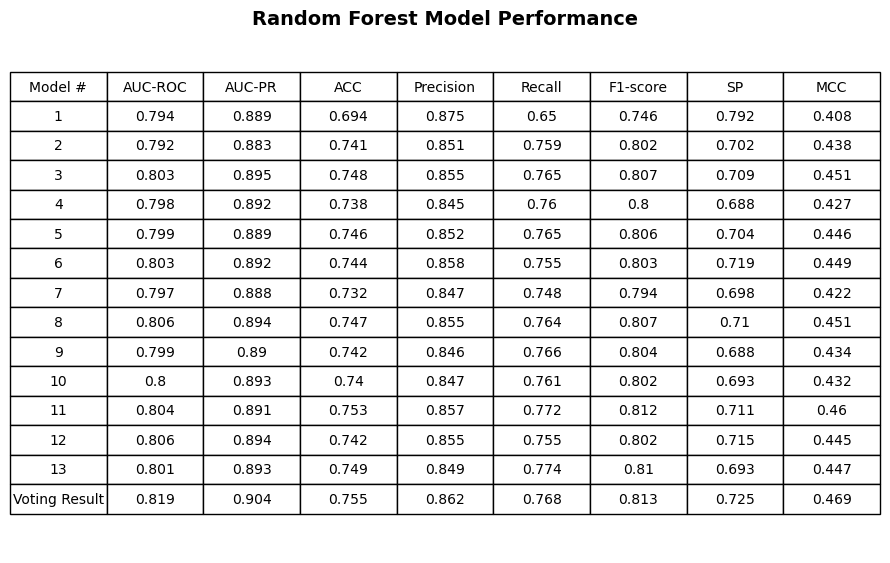

In [19]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(figsize=(9, len(results_df)*0.41))


ax.axis('off')
table = ax.table(cellText=results_df.values,
                 colLabels=results_df.columns,
                 cellLoc='center',
                 loc='center')


table.scale(1, 1.5) 
table.auto_set_font_size(False)
table.set_fontsize(10)

plt.title("Random Forest Model Performance", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
